# Local Multi-Agent Code Review & Repair

A self-hosted system that reviews a Python repository, applies fixes, and verifies its own work against a test suite — running entirely on local hardware with no external API calls or rate limits. Model inference is served through llama.cpp and is hardware-agnostic; I validated the full stack on an AMD ROCm GPU.

## Why I built it

Most agentic coding demos assume a hosted frontier model behind an API. I wanted to know how far a small, locally-served open-weight model could be pushed on a real task — multi-file code review and repair — when the orchestration around it is doing the heavy lifting. The constraint (a 35B local model, limited context, no cloud fallback) is what makes the design interesting: the system has to stay reliable *despite* the model, not because of it.

## How it works

The system is a coordinator plus three role-scoped worker agents:

- a **coordinator** that takes a repo and a target file, dispatches the reviewers, and sequences the fix-and-verify loop;
- two **reviewers** running in parallel — one scoped to performance (loop-invariant work, quadratic patterns, redundant computation), one to readability (naming, dead code, function length);
- a **fixer** that consumes the merged findings, edits only the target file, and re-runs the tests until they pass.
Coordination is done through a **file-based rendezvous**: each reviewer writes its findings to a fixed path, and the coordinator's only job on each wake is to check which files exist and merge once both are present. This is the core design decision — it means the coordinator never has to carry review state across turns, which is exactly where a small local model tends to lose the thread and stall. The files are the single source of truth.

Repeatable behavior is packaged as a markdown "skill" injected into the agent's system prompt, so the same debugging procedure transfers to a repository the system has never seen without any new prompting.

## Results

- Drove a two-gate verifier — behavior tests must pass **and** the flagged performance/readability issues must actually be resolved — to a fully passing state on an unseen repository.
- Transferred the skill to a second, previously unseen Python repo with zero additional prompting.
- <!-- Optional, if you measure it: throughput of ~X tok/s on the AMD GPU; end-to-end review-fix-verify in ~Y minutes. -->
## Stack

Python · llama.cpp · Qwen3.6-35B (Q6_K, GGUF) · AMD ROCm · multi-agent orchestration

## Background & attribution

The multi-agent pattern was inspired by an AMD Advanced AI workshop on OpenClaw. I rebuilt the orchestration layer myself — the coordinator, the reviewer/fixer agents, the file-rendezvous protocol, and the two-gate verification loop — to understand and control the coordination logic rather than treat it as a black box.

<!-- Adjust the sentence above to match exactly what you rebuilt vs. reused — this is the one line an interviewer will test you on, so make it literally true. -->

## Roadmap

- Swap the file rendezvous for a proper message queue and compare reliability.
- Add a critic pass so the fixer's edits are reviewed before the verifier runs.
- Benchmark the same pipeline across model sizes to find the reliability floor.


---
### Setup the environment
First, make sure the paths for your environment are set correctly.

In [ ]:
%%bash
cat >> ~/.bashrc << 'EOF'

# Auto-configure llama-server path
if [ -z "$LLAMA_CONFIGURED" ]; then
  LLAMA_BIN=$(find /workspace -name 'llama-server' -type f 2>/dev/null | head -1 | xargs dirname)
  if [ -n "$LLAMA_BIN" ]; then
    export PATH="$LLAMA_BIN:$PATH"
    LLAMA_BUILD=$(dirname "$LLAMA_BIN")
    export LD_LIBRARY_PATH="$LLAMA_BIN:$LLAMA_BUILD:$LD_LIBRARY_PATH"
    export WORKSPACE_DIR=$(echo $LLAMA_BIN | cut -d'/' -f1-3)
    export HF_HOME="/models"
    export LLAMA_CONFIGURED=1
  fi
fi
EOF

### 🖥️ Open a new terminal and run Llama.cpp

Now, start Llama.cpp server and create an end-point for your LLM. Let's open a terminal using your Jupyter server. Then run the following command in this terminal to start the server:



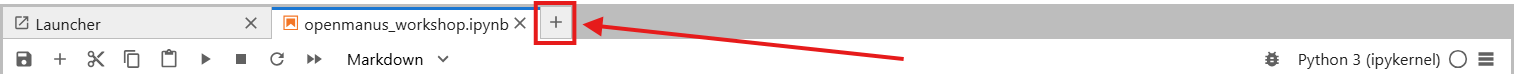

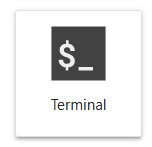


The cell below starts Llama.cpp to serve **Qwen3.6-35B** on AMD hardware.

Copy & paste this command into the terminal and press enter to launch your Llama.cpp server:

```bash
llama-server \
  -m /models/unsloth-Qwen3.6-35B-A3B-GGUF/Qwen3.6-35B-A3B-UD-Q6_K.gguf \
  --mmproj /models/unsloth-Qwen3.6-35B-A3B-GGUF/mmproj-BF16.gguf \
  -ngl 999 \
  --host 0.0.0.0 \
  --port 8080
```

**What this does:**
- Loads the Qwen3.6-35B Q6_K model with vision support
- Offloads layers to GPU (`-ngl 999`)
- Sets context length to 32K tokens
- Exposes OpenAI-compatible API on port 8080

Leave this running and return to this notebook to check if your server has started. This can take a few minutes for the model to load onto the GPU.


In [ ]:
# Check that llama-server is up and serving the model
import httpx

try:
    model_id = httpx.get("http://127.0.0.1:8080/v1/models", timeout=5).json()["data"][0]["id"]
    health = httpx.get("http://127.0.0.1:8080/health", timeout=5).json()
    print("READY - server is up, serving:", model_id)
    print("Health:", health)
except Exception as e:
    print("NOT READY - could not reach llama-server on port 8080.")
    print("Make sure the llama-server command is still running in its terminal,")
    print("give it a minute to load the model onto the GPU, then re-run this cell.")
    print("Details:", repr(e))

You should see output showing the server is healthy and the model is loaded.

---
## Section 1: Meet your OpenClaw agent

OpenClaw is already installed on your station, so you go straight to onboarding. Instead of clicking through a wizard, point it at your local model with one command.

### Onboard OpenClaw against your local model

The next cell onboards OpenClaw in non-interactive mode and points it at the local model you just started. When it finishes you should see `Updated config: ~/.openclaw/openclaw.json` and `Workspace OK`, that's your agent configured against the model on your GPU.

In [ ]:
%%bash
# Onboard OpenClaw against the local model, non-interactive
openclaw onboard --non-interactive --mode local \
  --auth-choice custom-api-key \
  --custom-base-url "http://localhost:8080/v1" \
  --custom-model-id "qwen" --custom-provider-id "llamacpp" \
  --custom-compatibility openai --custom-api-key "llamacpp" \
  --secret-input-mode plaintext --custom-image-input \
  --skip-channels --skip-search --skip-hooks --skip-ui \
  --skip-health --accept-risk

### Tune it and start the gateway

The next cell puts OpenClaw in **lean mode**, which keeps the tool interface simple enough for the local model to use reliably. It also launches the gateway **server** in the background that runs your agent, and it has to keep running the whole workshop.

In [ ]:
%%bash
# Tune OpenClaw for the local model: lean mode keeps the tool surface simple
openclaw config set agents.defaults.experimental.localModelLean true
echo "Config applied."

# Start the gateway in the background (this container has no systemd)
pkill -f "openclaw gateway" 2>/dev/null
sleep 1
nohup openclaw gateway run > ~/gateway.log 2>&1 &
sleep 3
echo "Gateway starting in background. Recent log:"
tail -n 8 ~/gateway.log

### 🖥️ Meet your agent (new terminal)

With the gateway runing in the background, you just need to start a TUI (terminal UI) to interact with your agent. Open a **new terminal** (`+` → Terminal) and run:

```bash
openclaw tui
```


### 🦞 Ask your OpenClaw agent
Once it's up, say hi to your agent to start the conversation. Say hi to your agent in the chat:

```text
Hi
```

This is where you'll chat with your OpenClaw agent whenever you see the 🦞 emoji.

### 👀 Behind the scenes: what just happened?

Those answers didn't just disappear. The agent's memory, personality, and skills are written in markdown files. You can read them, edit them, and version-control them. The agent wrote them to files in its **workspace**, a folder it reads on every message to remember who you are and how to behave.

The workspace has 7 files that get injected into every session:

```
~/.openclaw/workspace/
├── SOUL.md       ← WHO the agent is: values, personality, tone
├── AGENTS.md     ← HOW it operates: startup rules, memory, red lines
├── IDENTITY.md   ← WHO the agent is: name, creature, emoji, vibe
├── USER.md       ← WHO you are: context the agent reads about you
├── TOOLS.md      ← local environment notes (SSH hosts, device names, etc.)
├── HEARTBEAT.md  ← periodic background checks (empty by default)
├── BOOTSTRAP.md  ← first-run ritual (deleted after onboarding)
└── memory/       ← daily session logs (today + yesterday auto-loaded)
```

**SOUL.md is personality. AGENTS.md is policy.** Every message the agent receives, it re-reads both. Run the next cell to see all three key files at once.


In [ ]:
import pathlib

workspace = pathlib.Path.home() / ".openclaw" / "workspace"

for filename in ["IDENTITY.md", "SOUL.md"]:
    print("=" * 60)
    print(filename)
    print("=" * 60)
    print((workspace / filename).read_text())
    print()

print("=" * 60)
print("AGENTS.md  (truncated)")
print("=" * 60)
agents_text = (workspace / "AGENTS.md").read_text()
print(agents_text[:1200] + "\n\n... (truncated)")

---
## Section 2: Pull the App

Now let's give the agent something to work with. Ask the agent to clone the typing app and set it up.

### 🦞 Ask your OpenClaw agent
Ask your OpenClaw agent to clone the `Mahdi-CV/open_type_faster` repo and explain it to you. Here is an example:

```text
"Clone https://github.com/Mahdi-CV/open_type_faster, install its dependencies, and tell me how to run it"
```

Your agent uses shell tools to clone the repo, inspect its requirements, and install the libraries. It doesn't just answer, it runs the commands for you.

---
## Section 3: Fix a bug

### Step 1 - Spot the bug yourself

#### 🖥️ Open a new terminal and run the app

In a new terminal, follow the instructions OpenClaw provides on how to run `open_type_faster`.

Type for 30 seconds. When the results screen appears, look at the accuracy.

> **Something is off. Do you see it?**

### Step 2 - Ask OpenClaw to test

#### 🦞 Ask your OpenClaw agent

Ask your OpenClaw agent to fix the bug. Here is an example:

```text
"There seems to be an accuracy bug in this open_type_faster app, can you help identify and fix?"
```

---
## Section 4: Package as a Skill

What the agent just did was a one-off. A **skill** packages that behavior so it can be invoked on any Python project. Skills live in `~/.openclaw/workspace/skills/` as a folder containing a `SKILL.md` file with YAML frontmatter and step-by-step instructions. OpenClaw injects them into the system prompt automatically.

### 🦞 Ask your OpenClaw agent
Ask your OpenClaw agent to create a python debugger skill. Try sending this to your OpenClaw agent:

```text
"Create a skill called pytest-debugger in the skills directory. The SKILL.md must define these steps: 1) Read the tests/ folder to understand what is being tested. 2) Run pytest with verbose output and short tracebacks. 3) For each failing test, read the source file it references. 4) Identify the minimal fix, do not rewrite functions. 5) Apply the fix and re-run pytest to confirm. 6) Report: file changed, line changed, what was wrong, what the fix was."
```

The agent should show you where the skills file is saved. You can always ask it again to show you.

That file is all it takes. The skill lives in the workspace, alongside `IDENTITY.md` and `SOUL.md`, and OpenClaw injects it into every session automatically. Any time you ask the agent to debug a Python project, it has these steps to follow.

Skills are just markdown files. You can read them, edit them, and version-control them.

---
## Section 5: Using the Skill

The skill is now in the workspace and OpenClaw injects it into the agent's system prompt automatically, no special command needed.

The real value of a skill is applying it to a **completely different codebase**, one the agent has never seen, without writing a single new instruction. There's a broken Python project at `git@github.com:Mahdi-CV/buggy-py-mg.git`, hand it to the agent and watch the skill do the work.

#### 🦞 Ask your OpenClaw agent

```text
"/skill pytest-debugger git@github.com:Mahdi-CV/buggy-py-mg.git"
```

The agent will apply the exact same steps it used on `open_type_faster`, no re-explaining, no extra guidance.

---
## Section 6: Build a review panel (multi-agent)

You've built one agent that works on its own, but real teams don't ship on one person's say-so. Before code merges, you'd want multiple people to review changes. Let's build that panel.

You'll create a **coordinator** and two **specialist reviewers**. The coordinator hands the same file to both at once, each reviews it through its own lens, and the coordinator merges their findings into one report.

| Agent | Job |
|---|---|
| 🧭 **main** (coordinator) | Spawns the two reviewers in parallel and merges their reports into one review |
| ⚡ **performance** | Flags obvious inefficiencies: repeated work in loops, O(n²) patterns, needless re-computation |
| 📖 **readability** | Flags unclear names, dead code, long functions, anything that hurts maintainability |

Each reviewer is its own agent with one narrow focus. That's the whole idea of a multi-agent system: split the work by specialty, run it in parallel, and combine the results.

<p align="center"></p>

The orchestrator spawns two reviewer agents in parallel, then calls `sessions_yield` to wait until both finish. Each reviewer works in its own isolated session and writes its findings to a file in `/tmp/panel/`. Once both files exist, `main` wakes, reads them, and merges the two into one final report that lands in its own context, grouped by Performance and Readability.


### Step 1: Add the reviewer agents

A specialist reviewer is just another OpenClaw agent with its own workspace. You add one with a single command: `openclaw agents add <name> --non-interactive --workspace /root/.openclaw/workspace/<name>`

- `<name>` is how you'll refer to the agent, and how `main` spawns it.
- `--workspace` gives it its own folder, so its rules stay isolated from the other agents.
- Every new agent starts with a `BOOTSTRAP.md` (a first-run "introduce yourself" ritual). We delete it so the reviewer skips onboarding and is ready to work.

> 💡 Remember this command. You'll use the exact same one to add your own **Fixer** agent in the challenge.

Run the next cell to add both reviewers, one command each.

In [ ]:
%%bash
# Add the performance reviewer (its own agent, its own workspace)
openclaw agents add performance --non-interactive --workspace /root/.openclaw/workspace/performance
rm -f /root/.openclaw/workspace/performance/BOOTSTRAP.md   # skip the first-run ritual

# Add the readability reviewer, same command, different name
openclaw agents add readability --non-interactive --workspace /root/.openclaw/workspace/readability
rm -f /root/.openclaw/workspace/readability/BOOTSTRAP.md

echo "Created agents: performance, readability"

### Step 2: Let your main agent spawn the reviewers

Creating the reviewers isn't enough. Your `main` agent (the coordinator) has to be able to hand a file to each reviewer and collect their findings. It does that by **spawning** each reviewer as a sub-agent: `main` launches them, keeps working, and picks up their results when they finish. Two settings turn that on:

- **an allow-list of spawnable agents:** `agents.defaults.subagents.allowAgents` names exactly which agents `main` may spawn (`performance`, `readability`). By default an agent can only spawn itself.
- **the spawn tools on the surface:** add `sessions_spawn`, `sessions_yield`, and `subagents` to `main`'s allow-list so the tools are available.

The top-level `main` agent can already spawn one level of sub-agents by default, so those two settings are all you need. Run the next cell to apply them. (We leave lean mode on from the earlier setup, since the local llama.cpp backend needs the small tool payload lean mode provides.)


In [ ]:
%%bash
# The coordinator delegates by SPAWNING each reviewer as a sub-agent, then
# yielding until they finish. Two settings turn that on:

# 1. Let main spawn these specific agents as sub-agents (an explicit allow-list).
openclaw config set agents.defaults.subagents.allowAgents '["performance","readability"]' --strict-json

# 2. Put the spawn / yield tools on main's surface.
openclaw config set tools.alsoAllow '["sessions_spawn","sessions_yield","subagents"]' --strict-json

echo "main can now spawn: performance, readability"


### Step 3: Teach main how to run the panel

Right now `main` knows it *can* spawn the reviewers, but not *how* to run a review. We'll give it a reusable **Review Panel Protocol**: find the file, spawn both reviewers, then merge their findings.

The trick that makes this reliable on a local model is a simple **file rendezvous**. Each reviewer writes its findings to a fixed file (`/tmp/panel/performance.md`, `/tmp/panel/readability.md`). The coordinator spawns both, yields, and each time it wakes it just checks *how many of those two files exist*. When both are present it reads them and merges. The coordinator never has to hold review text in its head across turns, so it can't lose track and stall. The files are the single source of truth.

> 💡 The reviewers run in parallel as sub-agents. The coordinator waits with `sessions_yield` and is woken by a completion event when each one finishes.

Because this is an operating rule (not personality), it belongs in **AGENTS.md**, the agent's standard operating procedure. Personality and tone go in `SOUL.md`; rules go in `AGENTS.md`. The next cell appends the protocol to `main`'s AGENTS.md, once.


In [ ]:
%%bash
# Append the Review Panel Protocol to main's AGENTS.md (its operating manual), once
AGENTS="/root/.openclaw/workspace/AGENTS.md"
if ! grep -q "Review Panel Protocol" "$AGENTS" 2>/dev/null; then
cat >> "$AGENTS" << 'EOF'

## Review Panel Protocol

You coordinate two reviewer agents: "performance" and "readability". You review
NOTHING yourself. Reviewing the file inline is a FAILURE.

Each reviewer writes its findings to a file:
- performance -> /tmp/panel/performance.md
- readability -> /tmp/panel/readability.md

You do NOT need to remember review text between turns. The files are the source
of truth. Every time you wake up, just check which files exist.

When the user asks you to "run the review panel" on a repo URL or a file path:

1. Resolve the target to a full file path. If given a repo URL, clone it into your
   workspace with exec and locate the target source file. If given a file path,
   use it as-is.

2. Prepare the output folder with exec:
     mkdir -p /tmp/panel && rm -f /tmp/panel/performance.md /tmp/panel/readability.md

3. Spawn BOTH reviewers back to back, then yield once:
   a. Call sessions_spawn:
        agentId: "performance"
        context: "isolated"
        task: "Review <full path> for performance issues. Write findings to /tmp/panel/performance.md and reply with them."
   b. Call sessions_spawn:
        agentId: "readability"
        context: "isolated"
        task: "Review <full path> for readability issues. Write findings to /tmp/panel/readability.md and reply with them."
   c. Call sessions_yield with no parameters.

4. A completion event will wake you when a reviewer finishes. On EVERY wake, do
   exactly this:
   a. Run exec: ls /tmp/panel/performance.md /tmp/panel/readability.md 2>/dev/null | wc -l
   b. If the count is 2 (both files exist), go to step 5 and MERGE.
   c. If the count is less than 2, call sessions_yield again with no parameters to
      wait for the other reviewer. Do not reply to the user yet.

5. MERGE (only when both files exist):
   a. Run exec: cat /tmp/panel/performance.md and exec: cat /tmp/panel/readability.md
   b. Write ONE merged reply with a "Performance" section (the performance file
      contents) and a "Readability" section (the readability file contents).
      Output it directly to the user. You are done. Do NOT yield again.

Rules:
- context MUST be "isolated" ("fork" will error across different agents).
- Spawn both reviewers before the first yield. Never review anything yourself.
- The files are the source of truth. Never say you are "still waiting" for a
  review whose file already exists. Once both files exist, merge and finish.
EOF
  echo "Review Panel Protocol added to main AGENTS.md"
else
  echo "Review Panel Protocol already present in main AGENTS.md"
fi


### Step 4: Restart the gateway

The gateway reads its agents and workspace files fresh when it starts, so a restart is the surest way to load your new reviewers and the protocol you just added. The next cell stops the running gateway and launches it again in the background.

In [ ]:
%%bash
# Restart the gateway to load the new reviewers and protocol
pkill -f "openclaw gateway"
sleep 1
nohup openclaw gateway run > ~/gateway.log 2>&1 &
sleep 3
echo "Gateway restarted. Recent log:"
tail -n 8 ~/gateway.log

### Step 5: Brief each reviewer, in your agent chat

The restart in Step 4 makes your earlier TUI session stale (that's the `session file changed` error if you keep using it), so start a **fresh session** first. If your TUI is still open, type `/exit` (or press Ctrl-C), then relaunch it:

```bash
openclaw tui
```

A fresh session reconnects to the restarted gateway and loads the new reviewers and the Review Panel Protocol. You'll do everything from here: brief the reviewers, then run the panel.

A sub-agent only reads its own `AGENTS.md`, so give each reviewer its job once and have it save the rules. For each agent, switch to it with `/agent <name>`, send its brief, then move to the next.

#### **1. ⚡ performance**:
##### 🦞 Ask your OpenClaw agent
Type 
```bash
/agent performance
```
then send:

```text
"You are the Performance reviewer. When given a file path, read that file and report ONLY performance issues: repeated work inside loops, O(n^2) patterns, redundant computation, and needless allocations. For each issue give: file:line, why it's slow, and a one-line fix. If you find nothing, say "No performance issues found." Always save your complete findings to /tmp/panel/performance.md before you reply, then reply with them too. Save these rules to your AGENTS.md."
```

#### **2. 📖 readability**: 
##### 🦞 Ask your OpenClaw agent
Type 
```bash
/agent readability
```
then send:

```text
"You are the Readability reviewer. When given a file path, read that file and report ONLY readability and maintainability issues: unclear names, dead code, long functions, missing structure. For each issue give: file:line, the problem, and a one-line suggestion. If you find nothing, say "No readability issues found." Always save your complete findings to /tmp/panel/readability.md before you reply, then reply with them too. Save these rules to your AGENTS.md."
```

#### **3. Switch back**
##### 🦞 Ask your OpenClaw agent
Type 
```bash
/agent main
```
to switch back to the coordinator. You're ready to run the panel.


### Step 6: Run the review panel

Back in your agent chat, make sure you're on your **main** agent (type `/agent main` if not). Your main agent already knows how to run the panel, you taught it the **Review Panel Protocol** in its AGENTS.md during setup, so the ask is now a single line.

We'll point it at a small sales-report script that runs fine but was written in a hurry, it's slow and messy, so both reviewers have plenty to find.

> ⏱️ The coordinator spawns both reviewers, waits while they work in parallel, then merges what they wrote. Each reviewer works in its own session, through its own lens.

#### 🦞 Ask your OpenClaw agent
Type
```bash 
/reset
```
in your agent chat before you run the panel. It clears main's conversation so the local model starts from a small, fast context. The panel spawns two sub-agents and waits for both, and a long history carried over from the earlier steps can make it crawl.

#### 🦞 Send this in your agent chat

```text
"Run the review panel on https://github.com/Mahdi-CV/sloppy-sales (the file to review is report.py)."
```

Because the orchestration lives in the agent's AGENTS.md, that one line is enough: it clones the repo, finds `report.py`, spawns both reviewers, each of which writes its findings to `/tmp/panel/`, then merges their findings into one review grouped by Performance / Readability.

> 💡 Point it at any repo or file: `Run the review panel on <path>`. Same protocol, no re-briefing needed.

### 👀 What just happened

Each reviewer ran as its own agent, in its own session, on the same file. The coordinator spawned both, waited while they worked in parallel, and each reviewer wrote its findings to a file in `/tmp/panel/`. When both files were present, the coordinator read them and merged both into a single review grouped by Performance / Readability.

That file rendezvous is the trick: the coordinator never has to remember review text across turns, it just checks which files exist and merges once both are there. No lost results, no stalling.

You didn't write any orchestration code. You created two focused agents and gave one coordinator permission to spawn them. That is a multi-agent system: specialization plus delegation.

---
## Section 7: The Challenge, close the loop with a Fixer

So far your panel only *advises*, it finds problems but a human still fixes them. Time to make it act. You'll add a **third agent, a Fixer**, that takes the reviewers' findings, applies them, and drives the code to green. That turns your two-agent panel into a full three-agent system that reviews, fixes, and verifies on its own.

There's a small buggy repo waiting at `git@github.com:Mahdi-CV/catch-the-bug.git`. It has a few real behavior bugs **and** some genuinely messy code planted for your reviewers to catch.

### The system you're building

<p align="center"></p>

The reviewers never talk to each other. They hand their findings to `main` through two files in `/tmp/panel/`, `main` merges them, then passes them to the Fixer. Those files are the shared bus between agents

In [ ]:
%%bash
# Start from a clean slate: clear any reviews left over from Section 6 so the
# panel and the Fixer only ever see this challenge's findings.
rm -f /tmp/panel/performance.md /tmp/panel/readability.md
echo "cleared /tmp/panel, everyone starts clean"


### 🦞 Ask your OpenClaw agent
Type
```bash 
/reset
```
in your agent chat before you continue. It clears main's conversation so the local model starts from a small, fast context.

### Your mission, in three steps

1. **Add and brief a Fixer agent.** Grow the panel from two agents to three, and let `main` spawn it.
2. **Run the loop.** Have the panel review `typing_stats.py`, then hand its findings to the Fixer to apply. Keep the merged review, you'll show it.
3. **Qualify.** Run `verify.py` and clear both gates to earn your completion code.

Try each step yourself first, you've already seen every piece in Section 6. Stuck? Open the matching hint.

<details>
<summary>💡 Hint 1, add and brief the Fixer</summary>

A Fixer is just another agent, nothing new here:

1. **Add the agent** the same way you added the reviewers in Step 1 (the `openclaw agents add ... --workspace ...` command, then delete its `BOOTSTRAP.md`).
2. **Let `main` spawn it** by adding `fixer` to the spawn allow-list you set in Step 2 (`agents.defaults.subagents.allowAgents`, now with three names).
3. **Reload the gateway** so it picks up the new agent and allow-list: run the **Reload the gateway** cell just below these hints.

Then open a fresh TUI, switch to it with `/agent fixer`, and **write your own brief**. There's no fixed script, but a good brief hits these points:

- its one job: apply the reviewers' findings and make the failing tests pass
- where the findings live: the panel writes them to `/tmp/panel/performance.md` and `/tmp/panel/readability.md`
- keep edits minimal, and only to the file under review
- never touch anything under `tests/` or the verification script
- after editing, re-run the tests to confirm they pass

End the brief by asking it to save those rules to its `AGENTS.md` so they stick, then switch back with `/agent main`.

</details>

<details>
<summary>💡 Hint 2, run the review, then hand off to the Fixer</summary>

Drive it in two one-line asks. One job per turn is what keeps the local model reliable:

```text
"Run the review panel on https://github.com/Mahdi-CV/catch-the-bug (the file to review is typing_stats.py)."
```

When the merged review comes back:

```text
"Now spawn the fixer on the typing_stats.py you just reviewed so it applies the panel's findings and gets the tests green."
```

If `main` won't reliably spawn the Fixer from that plain ask, teach it a recipe, exactly like the Review Panel Protocol you added in Step 3. Add a short **Fixer Handoff Protocol** to main's `AGENTS.md` that spells out, in order, what it should do when you ask it to run the fixer:

- work out the full path of the file that was just reviewed
- `sessions_spawn` the `fixer` with `context: "isolated"` and a task that points it at the two `/tmp/panel/*.md` files and that file path
- `sessions_yield` to wait while the fixer works
- when the fixer wakes it, relay the report and do not yield again

Because you changed main's `AGENTS.md`, run the **Reload the gateway** cell below again so main loads the new protocol.

</details>

<details>
<summary>💡 Hint 3, qualify</summary>

Let your agent close the loop. From `main`, ask it to run the qualifier inside the cloned repo and report back:

```text
"In the catch-the-bug repo, install requirements and run verify.py, then show me exactly what it prints."
```

That runs the two-gate check for you:

```bash
pip install -r requirements.txt
python verify.py
```

`verify.py` has two gates: the behavior tests must pass, **and** the perf/readability issues the reviewers flagged must actually be gone. If it reports findings still remain, it names them, send the Fixer back with that specific list. When both gates pass it prints your completion code. Show that code **plus your panel's review output** to a workshop host to claim your gift. 🎁

> Do not edit the tests or `verify.py`. Fix the module, not the checks. Correct behavior is defined by the tests in `tests/`.

</details>

### Reload the gateway

Run this whenever you change something the gateway loads at startup: the spawn allow-list in **Hint 1**, or main's `AGENTS.md` in **Hint 2**. Running it when nothing changed is harmless, it just guarantees your latest edits are picked up.

In [ ]:
%%bash
# Reload the gateway so your latest allow-list / AGENTS.md changes take effect
pkill -f "openclaw gateway"
sleep 1
nohup openclaw gateway run > ~/gateway.log 2>&1 &
sleep 3
echo "Gateway restarted. Recent log:"
tail -n 8 ~/gateway.log

### The goal

A three-agent system you built, running on your AMD GPU: two reviewers that flag the problems in a repo they've never seen, and a Fixer that acts on their findings and drives the code until `verify.py` goes green and hands you a completion code. Review, fix, verify, with no human in the loop.

> 💡 Keep each agent's brief to ONE job. The panel works because every agent has a narrow, clear focus. The reviewers find, the Fixer acts. Don't let the Fixer freelance, it should apply what the reviewers surfaced.


## Your Mission

Add a Fixer agent, point your three-agent panel at `catch-the-bug`, let the reviewers flag the issues and the Fixer apply them, and get `verify.py` to green. Show your completion code and your panel's review to claim your gift, all on local AMD hardware. 🔬🦞🎁